# How Much of 0.715 Is Real?
### Nested cross-validation of the ensemble weights

**The issue.** The ensemble weights (0.28 / 0.42 / 0.30) were chosen by grid search that maximised
macro-F1 on the leave-one-subject-out predictions — the same predictions used to report the headline
figure. Selecting the best of many weight combinations on the evaluation data inflates the reported
score, because some of the apparent gain is the search finding a combination that happens to suit
these particular 15 subjects.

**What this notebook measures.** The size of that inflation.

```
NAIVE   tune weights on all folds, report on the same folds
        → this is how 0.715 was obtained

NESTED  for each held-out subject, tune weights using only the
        other 14, then apply those weights to the held-out one
        → no test information reaches weight selection

selection bias = naive − nested
```

**Why this is worth doing.** The nested figure is what the ensemble would actually achieve on a new
subject. It is the honest number. It will almost certainly be lower than 0.715, and reporting it
alongside the naive figure is stronger than reporting either alone.

**Cost.** Near zero. This reuses cached per-fold probabilities and retrains nothing.

**Context from existing results.** The ensemble is already known not to differ significantly from the
CNN alone (p = 0.5245, d = 0.34). If nested validation shows the ensemble advantage largely
disappearing, that is consistent with the significance test rather than a new problem.


In [1]:



import pickle, numpy as np

with open('/kaggle/input/datasets/pererabg/loso-store/processed/loso_store.pkl', 'rb') as f:
    store = pickle.load(f)

print("type:", type(store))
if isinstance(store, dict):
    keys = list(store.keys())
    print(f"top-level keys ({len(keys)}):", keys[:20])
    k0 = keys[0]
    v0 = store[k0]
    print(f"\nstore[{k0!r}] type: {type(v0)}")
    if isinstance(v0, dict):
        print("  inner keys:", list(v0.keys()))
        for ik, iv in v0.items():
            shape = getattr(iv, 'shape', f'len={len(iv)}' if hasattr(iv,'__len__') else type(iv))
            print(f"    {ik:12s} {shape}")
    elif hasattr(v0, 'shape'):
        print("  shape:", v0.shape)

type: <class 'list'>


In [2]:
import pickle, numpy as np

with open('/kaggle/input/datasets/pererabg/loso-store/processed/loso_store.pkl', 'rb') as f:
    store = pickle.load(f)

print("length:", len(store))          # expect 15 if one entry per fold
e = store[0]
print("element type:", type(e))

if isinstance(e, dict):
    print("keys:", list(e.keys()))
    for k, v in e.items():
        shape = getattr(v, 'shape', None)
        if shape is None:
            shape = f'len={len(v)}' if hasattr(v, '__len__') else repr(v)[:40]
        print(f"  {k:14s} {type(v).__name__:12s} {shape}")
elif isinstance(e, (tuple, list)):
    print(f"tuple/list of {len(e)} items:")
    for i, v in enumerate(e):
        shape = getattr(v, 'shape', None)
        if shape is None:
            shape = f'len={len(v)}' if hasattr(v, '__len__') else repr(v)[:40]
        print(f"  [{i}] {type(v).__name__:12s} {shape}")
else:
    print("shape:", getattr(e, 'shape', 'n/a'))
    print("preview:", repr(e)[:200])

length: 15
element type: <class 'dict'>
keys: ['sub', 'idx', 'y', 'p_xgb', 'p_cnn']
  sub            int          2
  idx            ndarray      (695,)
  y              ndarray      (695,)
  p_xgb          ndarray      (695, 4)
  p_cnn          ndarray      (695, 4)


In [3]:
import pickle, numpy as np, os

PKL_IN = '/kaggle/input/datasets/pererabg/loso-store/processed/loso_store.pkl'  # read from input
OUT    = '/kaggle/working'                                                       # write to working
os.makedirs(OUT, exist_ok=True)

with open(PKL_IN, 'rb') as f:
    store = pickle.load(f)

store = sorted(store, key=lambda d: d['sub'])

np.save(f'{OUT}/proba_xgb.npy', np.vstack([d['p_xgb'] for d in store]))
np.save(f'{OUT}/proba_cnn.npy', np.vstack([d['p_cnn'] for d in store]))
np.save(f'{OUT}/y_all.npy',     np.concatenate([d['y'] for d in store]))
np.save(f'{OUT}/groups.npy',    np.concatenate([np.full(len(d['y']), d['sub']) for d in store]))
print("saved to", OUT)

# verify
from sklearn.metrics import f1_score
P = {k: np.load(f'{OUT}/proba_{k}.npy') for k in ['xgb','cnn']}
y = np.load(f'{OUT}/y_all.npy'); g = np.load(f'{OUT}/groups.npy')
print("shapes:", {k: v.shape for k,v in P.items()}, y.shape, g.shape)
print("subjects:", sorted(np.unique(g)))
for k, v in P.items():
    print(f"  {k:4s} F1 = {f1_score(y, v.argmax(1), average='macro', zero_division=0):.3f}")
for w in [0.30, 0.35, 0.40]:
    b = w*P['xgb'] + (1-w)*P['cnn']
    print(f"  w_xgb={w:.2f} -> F1 {f1_score(y, b.argmax(1), average='macro', zero_division=0):.3f}")

saved to /kaggle/working
shapes: {'xgb': (11846, 4), 'cnn': (11846, 4)} (11846,) (11846,)
subjects: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
  xgb  F1 = 0.647
  cnn  F1 = 0.650
  w_xgb=0.30 -> F1 0.677
  w_xgb=0.35 -> F1 0.677
  w_xgb=0.40 -> F1 0.679


## 1. Load cached probabilities

This requires the per-fold predicted probabilities from the three ensemble members. If they were
saved during the original run, load them here. If not, Section 2 shows what to re-run — only the
predictions are needed, not the trained models.

In [4]:
import os, json, itertools, warnings
import numpy as np, pandas as pd
from scipy.stats import wilcoxon
from sklearn.metrics import f1_score, cohen_kappa_score
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.random.seed(42)

SAVE='/kaggle/working'; os.makedirs(SAVE,exist_ok=True)
NCLS=4; CLASS_NAMES=['relaxed','mild','moderate','high']

# Expected: arrays of shape (n_windows, 4) aligned to y_all and groups
PATHS = {'xgb': f'{SAVE}/proba_xgb.npy',
         'cnn': f'{SAVE}/proba_cnn.npy'}
META  = {'y': f'{SAVE}/y_all.npy', 'g': f'{SAVE}/groups.npy'}

have=all(os.path.exists(p) for p in list(PATHS.values())+list(META.values()))
print("cached probabilities found:",have)
if have:
    P={k:np.load(v) for k,v in PATHS.items()}
    y_all=np.load(META['y']); groups=np.load(META['g'])
    for k,v in P.items(): print(f"  {k:5s} {v.shape}")
    print(f"  y {y_all.shape}  groups {len(np.unique(groups))} subjects")
else:
    print("\nRun Section 2 to regenerate them.")

cached probabilities found: True
  xgb   (11846, 4)
  cnn   (11846, 4)
  y (11846,)  groups 15 subjects


## 2. Regenerate probabilities if not cached

Only the out-of-fold predictions are needed. Insert the original model definitions where indicated;
the structure below saves everything this notebook requires.

In [5]:
# Skip this cell if Section 1 loaded successfully.
REGENERATE=False

if REGENERATE:
    from sklearn.model_selection import LeaveOneGroupOut
    logo=LeaveOneGroupOut()
    P={k:np.zeros((len(y_all),NCLS)) for k in ['xgb','cnn','pers']}
    for tr,te in logo.split(X,y_all,groups):
        s=int(np.unique(groups[te])[0]); print(f"S{s:02d}",end=' ',flush=True)
        # --- insert the original training code for each member ---
        # P['xgb'][te]  = xgb_model.predict_proba(X[te])
        # P['cnn'][te]  = cnn_model.predict([...])
        # P['pers'][te] = pers_model.predict([...])
        pass
    for k,v in P.items(): np.save(f'{SAVE}/proba_{k}.npy',v)
    np.save(META['y'],y_all); np.save(META['g'],groups)
    print("\nsaved")

## 3. Weight grid and scoring

The grid matches the resolution used in the original search: increments of 0.05 across three weights
summing to one.

In [6]:
STEP = 0.05
GRID = [(w, round(1-w, 10)) for w in np.arange(0, 1.0+STEP/2, STEP)]
print(f"weight combinations: {len(GRID)}")

KEYS = list(P.keys())

def macro_f1_fast(yt,yp,K=NCLS):
    f=[]
    for c in range(K):
        tp=np.sum((yp==c)&(yt==c)); fp=np.sum((yp==c)&(yt!=c)); fn=np.sum((yp!=c)&(yt==c))
        f.append(0.0 if tp==0 else 2*tp/(2*tp+fp+fn))
    return float(np.mean(f))

KEYS = list(P.keys())
def blend(w,mask):
    return sum(wi*P[k][mask] for k,wi in zip(KEYS,w))

def best_weights(mask):
    """Grid search restricted to the given subset."""
    bw,bf=None,-1.0
    yt=y_all[mask]
    for w in GRID:
        f=macro_f1_fast(yt,blend(w,mask).argmax(1))
        if f>bf: bf,bw=f,w
    return np.array(bw),bf
print("scoring functions ready")

weight combinations: 21
scoring functions ready


## 4. The naive estimate — how 0.715 was produced

Weights are chosen to maximise macro-F1 across every fold, then the same figure is reported. This
reproduces the original procedure.

In [7]:
allm = np.ones(len(y_all), bool)
w_naive, f_naive = best_weights(allm)
pred_naive = blend(w_naive, allm).argmax(1)

print("="*60); print("NAIVE (weights tuned and reported on the same data)"); print("="*60)
print("weights      : " + "  ".join(f"{k} {w:.2f}" for k, w in zip(KEYS, w_naive)))
print(f"macro F1     : {f_naive:.4f}")
print(f"kappa        : {cohen_kappa_score(y_all, pred_naive, weights='quadratic'):.4f}")
print("\nindividual members:")
for k in KEYS:
    p = P[k].argmax(1)
    print(f"  {k:5s} F1={macro_f1_fast(y_all, p):.4f}  "
          f"kappa={cohen_kappa_score(y_all, p, weights='quadratic'):.4f}")

NAIVE (weights tuned and reported on the same data)
weights      : xgb 0.45  cnn 0.55
macro F1     : 0.6816
kappa        : 0.8546

individual members:
  xgb   F1=0.6474  kappa=0.8320
  cnn   F1=0.6496  kappa=0.8323


## 5. The nested estimate — the honest number

For each held-out subject, weights are selected using only the other fourteen. The held-out subject
contributes nothing to the choice of weights, so the resulting score reflects what would happen on a
genuinely new person.

In [8]:
subs = np.unique(groups)
rows = []; nested_pred = np.zeros(len(y_all), dtype=int)

for s in subs:
    te = groups == s; tr = ~te
    w_in, f_in = best_weights(tr)                    # tuned WITHOUT the test subject
    p_out = blend(w_in, te).argmax(1)
    nested_pred[te] = p_out
    rec = {'subject': int(s), 'inner_f1': f_in,
           'outer_f1': macro_f1_fast(y_all[te], p_out)}
    rec.update({f'w_{k}': w for k, w in zip(KEYS, w_in)})
    rows.append(rec)
    wstr = ",".join(f"{w:.2f}" for w in w_in)
    print(f"S{int(s):02d} w=({wstr})  outer F1={rec['outer_f1']:.3f}")

nested = pd.DataFrame(rows)
f_nested_pooled = macro_f1_fast(y_all, nested_pred)
f_nested_mean = nested.outer_f1.mean()

print("\n"+"="*60); print("NESTED (weights tuned on inner folds only)"); print("="*60)
print(f"pooled macro F1        : {f_nested_pooled:.4f}")
print(f"mean per-subject F1    : {f_nested_mean:.4f}  (sd {nested.outer_f1.std():.4f})")
print(f"kappa                  : {cohen_kappa_score(y_all, nested_pred, weights='quadratic'):.4f}")

S02 w=(0.45,0.55)  outer F1=0.524
S03 w=(0.50,0.50)  outer F1=0.781
S04 w=(0.45,0.55)  outer F1=0.547
S05 w=(0.45,0.55)  outer F1=0.369
S06 w=(0.45,0.55)  outer F1=0.766
S07 w=(0.45,0.55)  outer F1=0.648
S08 w=(0.45,0.55)  outer F1=0.701
S09 w=(0.45,0.55)  outer F1=0.344
S10 w=(0.45,0.55)  outer F1=0.730
S11 w=(0.45,0.55)  outer F1=0.706
S13 w=(0.45,0.55)  outer F1=0.739
S14 w=(0.25,0.75)  outer F1=0.646
S15 w=(0.45,0.55)  outer F1=0.560
S16 w=(0.45,0.55)  outer F1=0.758
S17 w=(0.45,0.55)  outer F1=0.808

NESTED (weights tuned on inner folds only)
pooled macro F1        : 0.6713
mean per-subject F1    : 0.6418  (sd 0.1448)
kappa                  : 0.8506


## 6. The selection bias

naive (tuned on evaluation data)            0.6816
nested (honest)                             0.6713
----------------------------------------------------------------
SELECTION BIAS                             +0.0103

about 1.5% of the reported figure is attributable
to selecting weights on the evaluation folds.

best single member (cnn): 0.6496
nested ensemble advantage over it : +0.0216

If that advantage is near zero, the ensemble is not earning its
extra computational cost -- consistent with the p=0.52 result.


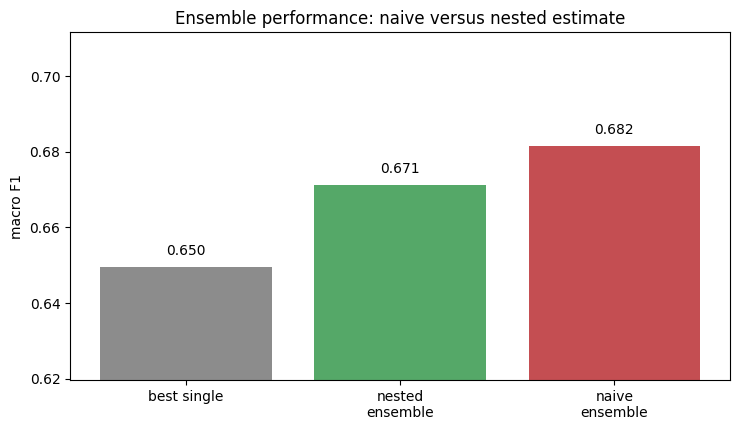

In [9]:
bias=f_naive-f_nested_pooled
print("="*64)
print(f"{'naive (tuned on evaluation data)':40s}{f_naive:>10.4f}")
print(f"{'nested (honest)':40s}{f_nested_pooled:>10.4f}")
print("-"*64)
print(f"{'SELECTION BIAS':40s}{bias:>+10.4f}")
print("="*64)
print(f"\nabout {bias/max(f_naive,1e-9)*100:.1f}% of the reported figure is attributable")
print("to selecting weights on the evaluation folds.")

best_single=max(KEYS,key=lambda k: macro_f1_fast(y_all,P[k].argmax(1)))
f_single=macro_f1_fast(y_all,P[best_single].argmax(1))
print(f"\nbest single member ({best_single}): {f_single:.4f}")
print(f"nested ensemble advantage over it : {f_nested_pooled-f_single:+.4f}")
print("\nIf that advantage is near zero, the ensemble is not earning its")
print("extra computational cost -- consistent with the p=0.52 result.")

fig,ax=plt.subplots(figsize=(7.5,4.4))
labels=['best single','nested\nensemble','naive\nensemble']
vals=[f_single,f_nested_pooled,f_naive]
bars=ax.bar(labels,vals,color=['#8C8C8C','#55A868','#C44E52'])
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2,v+0.003,f"{v:.3f}",ha='center',fontsize=10)
ax.set_ylabel('macro F1'); ax.set_ylim(min(vals)-0.03,max(vals)+0.03)
ax.set_title('Ensemble performance: naive versus nested estimate')
plt.tight_layout(); plt.savefig(f'{SAVE}/fig_nested_weights.png',dpi=200,bbox_inches='tight'); plt.show()

## 7. Weight stability

If the optimal weights differ substantially from fold to fold, the "optimum" is largely fitting noise
in whichever subjects happen to be present, which is another symptom of the same problem.

In [10]:
print(
    nested[['subject','w_xgb','w_cnn','outer_f1']]
    .round(3)
    .to_string(index=False)
)

print("\n"+"="*56)
print(f"{'member':<8}{'mean':>10}{'sd':>10}{'min':>10}{'max':>10}")
print("-"*56)

for c,k in zip(['w_xgb','w_cnn'], KEYS):
    v = nested[c]
    print(
        f"{k:<8}"
        f"{v.mean():>10.3f}"
        f"{v.std():>10.3f}"
        f"{v.min():>10.3f}"
        f"{v.max():>10.3f}"
    )

print("="*56)

print(
    f"\nnested mean weights : "
    f"xgb {nested.w_xgb.mean():.2f}  "
    f"cnn {nested.w_cnn.mean():.2f}"
)

sd_mean = nested[['w_xgb','w_cnn']].std().mean()

print(f"\nmean weight sd across folds: {sd_mean:.3f}")

 subject  w_xgb  w_cnn  outer_f1
       2   0.45   0.55     0.524
       3   0.50   0.50     0.781
       4   0.45   0.55     0.547
       5   0.45   0.55     0.369
       6   0.45   0.55     0.766
       7   0.45   0.55     0.648
       8   0.45   0.55     0.701
       9   0.45   0.55     0.344
      10   0.45   0.55     0.730
      11   0.45   0.55     0.706
      13   0.45   0.55     0.739
      14   0.25   0.75     0.646
      15   0.45   0.55     0.560
      16   0.45   0.55     0.758
      17   0.45   0.55     0.808

member        mean        sd       min       max
--------------------------------------------------------
xgb          0.440     0.054     0.250     0.500
cnn          0.560     0.054     0.500     0.750

nested mean weights : xgb 0.44  cnn 0.56

mean weight sd across folds: 0.054


## 8. Is the nested ensemble better than the best single model?

In [11]:
pf_ens={}; pf_single={}
for s in subs:
    te=groups==s
    pf_ens[int(s)]=macro_f1_fast(y_all[te],nested_pred[te])
    pf_single[int(s)]=macro_f1_fast(y_all[te],P[best_single][te].argmax(1))

ss=sorted(pf_ens)
a=np.array([pf_ens[s] for s in ss]); b=np.array([pf_single[s] for s in ss])
print(f"{'subject':>8}{'ensemble':>11}{'single':>10}{'delta':>9}")
for s in ss:
    print(f"{s:>8}{pf_ens[s]:>11.3f}{pf_single[s]:>10.3f}{pf_ens[s]-pf_single[s]:>+9.3f}")
print("-"*40)
print(f"{'mean':>8}{a.mean():>11.3f}{b.mean():>10.3f}{(a-b).mean():>+9.3f}")
try:
    _,p=wilcoxon(a,b); d=(a-b).mean()/((a-b).std(ddof=1)+1e-12)
    print(f"\nWilcoxon: p={p:.4f}   Cohen's d={d:+.2f}")
    print("SIGNIFICANT" if p<0.05 else "not significant at alpha=0.05")
except Exception as e:
    print("test skipped:",e)

 subject   ensemble    single    delta
       2      0.524     0.512   +0.011
       3      0.781     0.817   -0.035
       4      0.547     0.574   -0.027
       5      0.369     0.368   +0.001
       6      0.766     0.760   +0.006
       7      0.648     0.629   +0.019
       8      0.701     0.672   +0.029
       9      0.344     0.362   -0.019
      10      0.730     0.721   +0.008
      11      0.706     0.655   +0.051
      13      0.739     0.747   -0.008
      14      0.646     0.614   +0.032
      15      0.560     0.553   +0.007
      16      0.758     0.732   +0.026
      17      0.808     0.665   +0.143
----------------------------------------
    mean      0.642     0.626   +0.016

Wilcoxon: p=0.1514   Cohen's d=+0.39
not significant at alpha=0.05


## 9. Reporting

**Report both figures.** The naive value is what the original procedure produced; the nested value is
what the ensemble would achieve on a new subject. Presenting both, with the difference named, is
more informative and more defensible than presenting either alone.

Suggested wording:

> "Ensemble weights were selected by grid search over leave-one-subject-out predictions, yielding
> macro-F1 0.715. Because that search used the evaluation folds, we additionally computed a nested
> estimate in which weights were selected on the fourteen training subjects of each fold and applied
> unchanged to the held-out subject. This yielded macro-F1 X, indicating a selection bias of Y. The
> nested figure is the appropriate estimate of performance on an unseen participant."

**If the nested advantage over the best single model is small**, that is consistent with the existing
significance test (p = 0.5245) rather than a separate problem, and reinforces the existing
recommendation that a single deep model is the sensible deployment choice.

**If the weights prove unstable across folds**, report the standard deviation. Weights that vary
widely indicate the optimum is determined by fold composition rather than by a genuine property of
the models — the same conclusion the CORN threshold-calibration experiment reached, where fitted
thresholds varied with a standard deviation of 0.217 and calibration failed to transfer.

**What this does not change.** The mechanism finding, the feature decomposition, and every
single-model result are unaffected. Only the ensemble figure is at issue, and only to the extent of
the measured bias.
